In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [3]:
TxnData = pd.read_csv('creditcard_transactions.csv')
print(TxnData.head())

        Time        V1        V2        V3        V4        V5        V6  \
0   90395.53  1.644640  0.742337 -2.071775 -0.050627  1.690391 -0.768515   
1   53925.07  1.381244  2.431082 -0.973213  0.286065  1.560448 -1.603609   
2   53330.62  0.793632 -0.583518  0.827823 -0.139391  0.480135  1.315760   
3  147464.05 -0.649246 -1.870897  1.456471 -0.347268  0.118482  0.195609   
4  141418.40  0.478166  1.165930  0.280154  1.304770 -0.220470 -1.943646   

         V7        V8        V9       V10       V11       V12       V13  \
0  0.042378 -1.838917  0.545155  0.798295  1.832636  1.849852 -1.000171   
1  0.961776  1.459579 -0.157447 -0.209395  0.358976  0.144916  0.992577   
2 -0.358735 -1.271801 -0.911189  0.867790 -1.324808 -0.814501 -0.869503   
3  2.358344 -0.647220 -0.148867  0.317461 -1.256500  0.091636  0.973493   
4 -0.118127 -0.051582 -0.054004 -1.577264 -1.362174 -0.473274 -0.016467   

        V14  Amount  Class  
0 -0.670472  110.45      0  
1  0.788817   29.88      0  
2 -1.

In [4]:
print("\nClass distribution:\n", TxnData['Class'].value_counts())
print("Fraud percentage: {:.2f}%".format(TxnData['Class'].mean() * 100))


Class distribution:
 Class
0    7880
1     120
Name: count, dtype: int64
Fraud percentage: 1.50%


In [5]:
print("\nMissing values per column:\n", TxnData.isnull().sum().sum(), "total")



Missing values per column:
 0 total


In [6]:
x = TxnData.drop(columns=['Class'])
y = TxnData['Class']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=7, stratify=y
)

In [8]:
print("\nTrain fraud cases:", y_train.sum(), "/", len(y_train))
print("Test fraud cases :", y_test.sum(), "/", len(y_test))


Train fraud cases: 96 / 6400
Test fraud cases : 24 / 1600


In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
print("\n" + "=" * 60)
print("BASELINE: Support Vector Machine (no resampling)")
print("=" * 60)


BASELINE: Support Vector Machine (no resampling)


In [11]:
svm_baseline = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=7)
svm_baseline.fit(x_train_scaled, y_train)

SVC(class_weight='balanced', probability=True, random_state=7)

In [12]:
y_pred_svm = svm_baseline.predict(x_test_scaled)
y_proba_svm = svm_baseline.predict_proba(x_test_scaled)[:, 1]

In [13]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


Accuracy : 0.999375
Precision: 1.0
Recall   : 0.9583333333333334
F1 score : 0.9787234042553191
ROC-AUC  : 1.0
Confusion Matrix:
 [[1576    0]
 [   1   23]]


In [14]:
print("\n" + "=" * 60)
print("Applying SMOTE to training data")
print("=" * 60)



Applying SMOTE to training data


In [15]:
smote = SMOTE(random_state=7)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After SMOTE :", dict(pd.Series(y_train_smote).value_counts()))

Before SMOTE: {0: np.int64(6304), 1: np.int64(96)}
After SMOTE : {0: np.int64(6304), 1: np.int64(6304)}


In [16]:
print("\n" + "=" * 60)
print("XGBoost (trained on SMOTE-resampled data)")
print("=" * 60)


XGBoost (trained on SMOTE-resampled data)


In [17]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=7
)
xgb_model.fit(x_train_smote, y_train_smote)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
y_proba_xgb = xgb_model.predict_proba(x_test_scaled)[:, 1]


In [19]:
y_pred_xgb_default = (y_proba_xgb >= 0.5).astype(int)


In [20]:
print("\n--- XGBoost @ default threshold = 0.50 ---")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_default))
print("Precision:", precision_score(y_test, y_pred_xgb_default))
print("Recall   :", recall_score(y_test, y_pred_xgb_default))
print("F1 score :", f1_score(y_test, y_pred_xgb_default))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_default))


--- XGBoost @ default threshold = 0.50 ---
Accuracy : 0.994375
Precision: 0.7586206896551724
Recall   : 0.9166666666666666
F1 score : 0.8301886792452831
ROC-AUC  : 0.9989953468697124
Confusion Matrix:
 [[1569    7]
 [   2   22]]


In [21]:
print("\n" + "=" * 60)
print("Threshold tuning")
print("=" * 60)



Threshold tuning


In [22]:
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_proba_xgb >= t).astype(int)) for t in thresholds]

In [23]:
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (max F1): {best_threshold:.2f}")

Best threshold (max F1): 0.97


In [24]:
y_pred_xgb_tuned = (y_proba_xgb >= best_threshold).astype(int)


In [25]:
print(f"\n--- XGBoost @ tuned threshold = {best_threshold:.2f} ---")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall   :", recall_score(y_test, y_pred_xgb_tuned))
print("F1 score :", f1_score(y_test, y_pred_xgb_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_tuned))
print(classification_report(y_test, y_pred_xgb_tuned))



--- XGBoost @ tuned threshold = 0.97 ---
Accuracy : 0.99625
Precision: 0.9090909090909091
Recall   : 0.8333333333333334
F1 score : 0.8695652173913043
Confusion Matrix:
 [[1574    2]
 [   4   20]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1576
           1       0.91      0.83      0.87        24

    accuracy                           1.00      1600
   macro avg       0.95      0.92      0.93      1600
weighted avg       1.00      1.00      1.00      1600



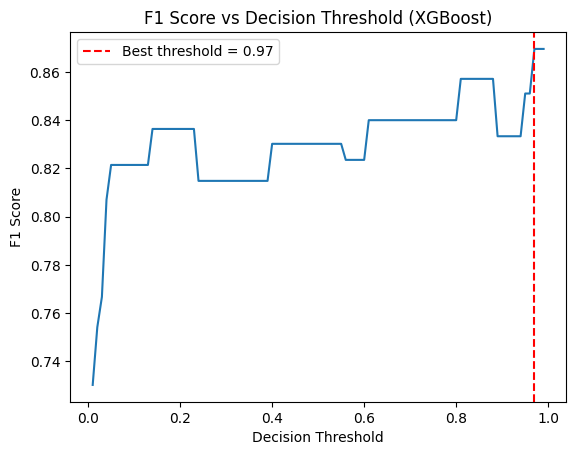

In [26]:
plt.figure()
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Decision Threshold (XGBoost)")
plt.legend()
plt.show()

In [27]:
importances = xgb_model.feature_importances_
feature_names = x.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 10 most important features:\n", importance_df.head(10))



Top 10 most important features:
    feature  importance
2       V2    0.635799
12     V12    0.171791
15  Amount    0.071013
5       V5    0.046807
4       V4    0.034163
9       V9    0.011961
6       V6    0.010177
10     V10    0.006759
14     V14    0.004405
1       V1    0.002716


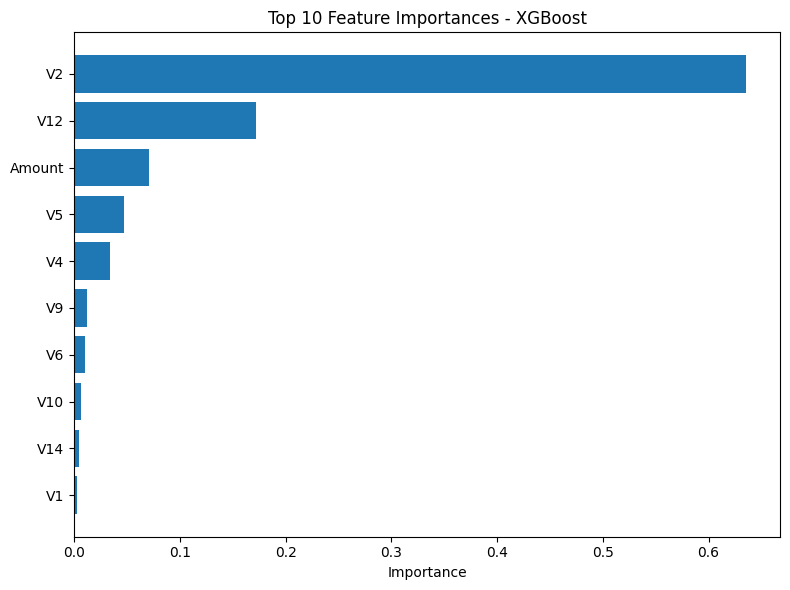

In [28]:
plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"][:10][::-1], importance_df["importance"][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

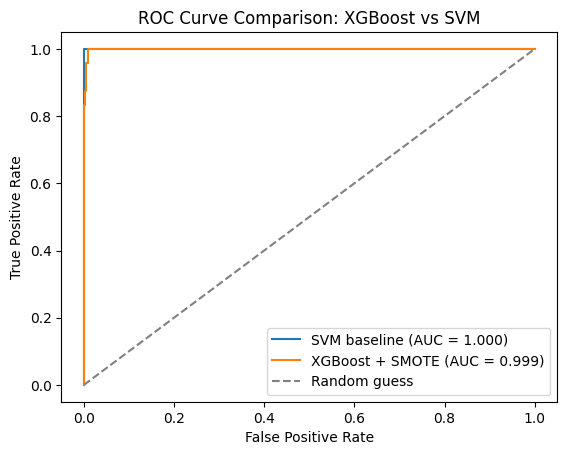

In [29]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure()
plt.plot(fpr_svm, tpr_svm, label=f"SVM baseline (AUC = {roc_auc_score(y_test, y_proba_svm):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost + SMOTE (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: XGBoost vs SVM")
plt.legend()
plt.show()

In [30]:
summary = pd.DataFrame({
    "Model": ["SVM baseline", "XGBoost + SMOTE (thr=0.50)", f"XGBoost + SMOTE (thr={best_threshold:.2f})"],
    "Precision": [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_xgb_default),
        precision_score(y_test, y_pred_xgb_tuned),
    ],
    "Recall": [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_xgb_default),
        recall_score(y_test, y_pred_xgb_tuned),
    ],
    "F1": [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_xgb_default),
        f1_score(y_test, y_pred_xgb_tuned),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_svm),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_xgb),
    ],
})
print("\n" + "=" * 60)
print("SUMMARY: SVM baseline vs XGBoost + SMOTE")
print("=" * 60)
print(summary.to_string(index=False))


SUMMARY: SVM baseline vs XGBoost + SMOTE
                     Model  Precision   Recall       F1  ROC-AUC
              SVM baseline   1.000000 0.958333 0.978723 1.000000
XGBoost + SMOTE (thr=0.50)   0.758621 0.916667 0.830189 0.998995
XGBoost + SMOTE (thr=0.97)   0.909091 0.833333 0.869565 0.998995
